# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


Os dados usados foram tratados posteriormente - balanceamento de classes, transformação de variáveis categóricas e separação de base de treino e teste.
Nesse projeto o método de árvore de decisão foi aplicado afim de criar modelos de previsões do score de crédito.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

### 1) Carregar e verificar as bases de treino e teste.

#### Carregar bases

In [5]:
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')



#### Verificação das bases
Apesar de cada base estar separada em X (variáveis explicativas) e y (variáveis rótulos/a serem previstas), elas devem ter o mesmo tamanho pois, para cada conjunto (linha) de X é preciso ter um rótulo y associado.
Além disso, as bases de X não devem conter a variável rótulo/a ser prevista.

In [8]:
print( "X teste reprovado" if 'Credit Score Encoded' in X_test.columns else "X teste não contém a variável rótulo.")
print( "X treino reprovado" if 'Credit Score Encoded' in X_train.columns else "X treino não contém a variável rótulo.")
print("X e y teste possuem o mesmo tamanho." if len(y_test)==len(X_test) else "X e y reprovados.")
print("X e y treino possuem o mesmo tamanho." if len(y_train)==len(X_train) else "X e y reprovados.")

X teste não contém a variável rótulo.
X treino não contém a variável rótulo.
X e y teste possuem o mesmo tamanho.
X e y treino possuem o mesmo tamanho.


In [9]:
X_test = X_test.drop(columns=['Credit Score Encoded'])
X_train = X_train.drop(columns=['Credit Score Encoded'])
print( "X teste reprovado" if 'Credit Score Encoded' in X_test.columns else "X teste não contém a variável rótulo.")
print( "X treino reprovado" if 'Credit Score Encoded' in X_train.columns else "X treino não contém a variável rótulo.")
print("X e y teste possuem o mesmo tamanho." if len(y_test)==len(X_test) else "X e y reprovados.")
print("X e y treino possuem o mesmo tamanho." if len(y_train)==len(X_train) else "X e y reprovados.")

KeyError: "['Credit Score Encoded'] not found in axis"

#### Verificar o balanceamento das variáveis rótulos da base de treino.
É preciso que o modelo seja treinado com uma base que contenha o mesmo número de dados de cada opção de variável a ser prevista. Caso contrário, haverá, especialmente para o modelo naive, um desequilíbrio no cálculo da probabilidade de ocorrência de cada y. Isso ocorre por que, resumidamente, se uma das opções for mais numerosa que outra, ela se torna mais frequente e, logo, mais provável que ela ocorra.

In [ ]:
train_balance = y_train.value_counts()
n0=train_balance[0]

for n in train_balance.items():
    #print(n0,n[1])
    #print(n0==n[1]) 
    print( "Balanceado" if n0==n[1] else "Desbalanceado")
    n0=n[1]

Balanceado
Balanceado
Balanceado


C:\Users\marina.freitas\AppData\Local\Temp\ipykernel_12476\2871665982.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n0=train_balance[0]


In [10]:
train_balance = y_train.value_counts()
n0=train_balance[0]

for n in train_balance.items():
    #print(n0,n[1])
    #print(n0==n[1]) 
    print( "Balanceado" if n0==n[1] else "Desbalanceado")
    n0=n[1]

Balanceado
Balanceado
Balanceado


C:\Users\marina.freitas\AppData\Local\Temp\ipykernel_16092\2871665982.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n0=train_balance[0]


# 2) Descrição do passo a passo para a aplicação do algoritmo da árvore de decisão

1. A aplicação da árvore de decisão incia após o tratamento dos dados e importação das bibliotecas pertinentes.
1. Para criar o modelo, deve-se configurar os parâmetros conforme seu objetivo. Cada método terá seus critérios específicos, por isso é importante conhecer como a biblioteca escolhida deve ser usada e escolher os parâmetros adequados. Por exemplo, para a biblioteca usada nesse projeto, scikit-learn, poems começar determinado o critério de divisão das decisões, Índice de Geni ou Entropia, e a semente da função pseudo-aleatória que influencia na formação do modelo. 
1. Determinados os parâmetros, a função `fit()` irá gerar o modelo a partir das bases de treino fornecidas, geralmente X-train e y_train.
1. Para uma avaliação incial, pode-se usar o modelo na base X de treino para obter a base Y prevista e comparar esses valores originais da base Y de treinho. 
1. Para obter um avaliação mais consistente, deve-se aplicar o modelo a base X de teste e comparar a base Y prevista com a base Y de teste original. A comparação pode ser feita com a função `classification_report()`, que retorna o valor de importantes parâmetros, tais como acurácia, precisão, revall e f1-score. A criação de uma matriz de criação é também uma estratégia importante para esse momento análise.
1. Caso se queira melhorar o modelo, há a opção de excluir do treino as informações menos relevantes, que influenciam menos nos valores da variável prevista/alvo. A propriedade `feature_importances_` do modelo indica quais variáveis explciativas tem maior peso na árvore de decisão, o que permite que aquelas com menor peso sejam excluidas da base. Esse processo contrui para evitar o overfitting.
1. Feito isso, um novo modelo é treinado a partir das bases de treino enxugadas.
1. A etapa de análise pode ser então repetida, avaliando-se se o modelo de fato melhorou e o que mais deve ser feito para aprimorá-lo.


# 3) Modelo de árvore de decisão 

Aplicação do algorítimo de árvore de decisão aos dados de treinamento originais, utilizando critério de Gini e random state = 0.

In [16]:
from sklearn.tree import DecisionTreeClassifier 

arvore_01 = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_01.fit(X_train, y_train)

# Aprimorando a exibição dos resultados
params = arvore_01.get_params()

parametros_descricao = [
    "ccp_alpha:\n    Este é o parâmetro de poda. Controla o custo de complexidade-complexidade poda (CCP). Valores maiores de ccp_alpha incentivam a poda, o que pode levar a uma árvore mais simples, evitando o overfitting.",
    "class_weight:\n    Peso associado às classes. Pode ser usado para lidar com conjuntos de dados desequilibrados, dando mais peso às classes menos representadas.",
    "criterion:\n    O critério usado para medir a qualidade da divisão em cada nó da árvore. 'gini' para índice de Gini ou 'entropy' para ganho de informação.",
    "max_depth:\n    A profundidade máxima da árvore. Controla a profundidade máxima que a árvore pode atingir. Limitar a profundidade pode ajudar a evitar overfitting.",
    "max_features:\n    O número máximo de características a serem consideradas ao procurar a melhor divisão. Pode ser um número ou uma proporção das características.",
    "max_leaf_nodes:\n   O número máximo de folhas na árvore. Limita o crescimento da árvore, ajudando a evitar overfitting.",
    "min_impurity_decrease:\n    Um nó será dividido se a divisão resultante diminuir a impureza ponderada por pelo menos esse valor.",
    "min_samples_leaf:\n    O número mínimo de amostras que deve estar presente em uma folha. Garante que cada folha da árvore tenha pelo menos esse número de amostras, ajudando a evitar que a árvore crie folhas com poucos dados e, assim, reduza o risco de overfitting.",
    "min_samples_split:\n    O número mínimo de amostras necessárias para dividir um nó interno. Controla o número mínimo de amostras necessárias para realizar uma divisão.",
    "min_weight_fraction_leaf:\n    A fração ponderada do número total de amostras que deve ser em uma folha.",
    'monotonic_cst',
    "random_state:\n    O estado aleatório usado para dividir os dados em conjuntos de treinamento e teste. Garante reprodutibilidade dos resultados.",
    "splitter:\n    A estratégia usada para escolher a divisão em cada nó. 'best' para escolher a melhor divisão ou 'random' para escolher uma divisão aleatória entre as melhores divisões."
]
i=0
for chave, valor in params.items():
    print(parametros_descricao[i])
    print(f"    {valor}")
    i+=1

ccp_alpha:
    Este é o parâmetro de poda. Controla o custo de complexidade-complexidade poda (CCP). Valores maiores de ccp_alpha incentivam a poda, o que pode levar a uma árvore mais simples, evitando o overfitting.
    0.0
class_weight:
    Peso associado às classes. Pode ser usado para lidar com conjuntos de dados desequilibrados, dando mais peso às classes menos representadas.
    None
criterion:
    O critério usado para medir a qualidade da divisão em cada nó da árvore. 'gini' para índice de Gini ou 'entropy' para ganho de informação.
    gini
max_depth:
    A profundidade máxima da árvore. Controla a profundidade máxima que a árvore pode atingir. Limitar a profundidade pode ajudar a evitar overfitting.
    None
max_features:
    O número máximo de características a serem consideradas ao procurar a melhor divisão. Pode ser um número ou uma proporção das características.
    None
max_leaf_nodes:
   O número máximo de folhas na árvore. Limita o crescimento da árvore, ajudando a evi

In [27]:

print("Comparação entre os 10 primeiros valores de previsão e os valores reais da base de treino:")
previsoes_treino = arvore_01.predict(X_train)

for l in range(10):
    print(f"Valor previsto = {previsoes_treino[l]} ---- Valor real = {y_train.values[l]} ")

from sklearn.metrics import classification_report

relatorio_treino = classification_report(y_train, previsoes_treino)
print("Relatório da Base de Treino")
print(relatorio_treino)


Comparação entre os 10 primeiros valores de previsão e os valores reais da base de treino:
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = Low ---- Valor real = ['Low'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = High ---- Valor real = ['High'] 
Valor previsto = High ---- Valor real = ['High'] 
Valor previsto = High ---- Valor real = ['High'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = High ---- Valor real = ['High'] 
Relatório da Base de Treino
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        84
        High       1.00      1.00      1.00        84
         Low       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00    

# 4) Aplicação do modelo aos dados de teste e avaliação dos resultados.

In [29]:

previsoes_teste = arvore_01.predict(X_test)
#acuracia = accuracy_score(y_test, previsoes)
relatorio_teste = classification_report(y_test, previsoes_teste)
print("Relatório de Classificação:")
print(relatorio_teste)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.86      1.00      0.92         6
        High       1.00      0.97      0.98        29
         Low       1.00      1.00      1.00         6

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41



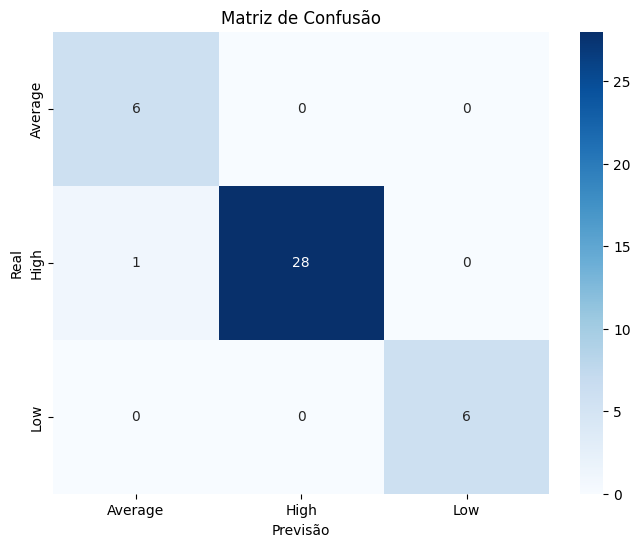

In [30]:
matriz_confusao = confusion_matrix(y_test, previsoes_teste)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Average', 'High', 'Low'],
            yticklabels=['Average', 'High', 'Low'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

#### Análise

Os valores do relatório para a base de treino indicam que o modelo se encaixou muito bem aos dados. Isso pode indica rum bom modelo, ou um over fitting.
Ao comparar com o relatório do modelo de teste, é verificado que os valores são muito similares, tendo seus valores alterados em função de apenas um erro. Para poder afirmar se há ou não overfitting, seri anecessário uma base de teste maior. Se o relatório permanecer equivalente, não há overfitting, se os dados do relatório piorarem, é bem possível que o modelo tenha sofrido com o overfitting.

# 5) Avaliação visual: Plot da árvore de decisão.

Profundidade da árvore: 5

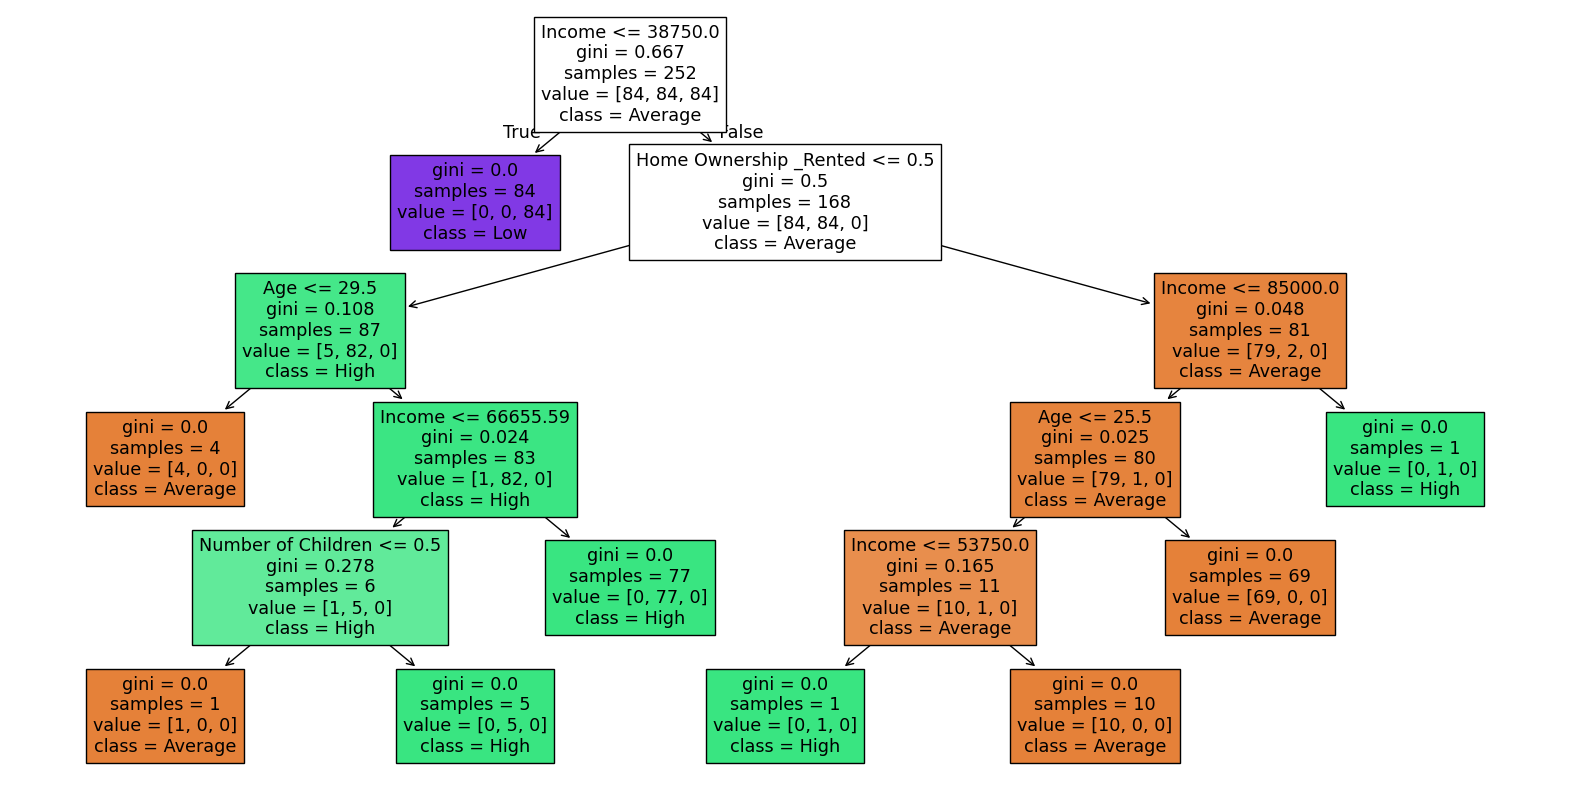

In [31]:
plt.figure(figsize=(20,10))
plot_tree(arvore_01, filled=True, feature_names=X_train.columns, class_names=['Average', 'High', "Low"])
plt.show()

# 6) Melhorar o modelo: identificar as 2 principais features do modelo.

Conforme indicado no gráfico abaixo, as duas principais características do modelo são home ownership rented e income.

Importância das Features:
Age: 0.0453
Income: 0.5241
Number of Children: 0.0099
Education Encoded: 0.0000
Marital Status_Single: 0.0000
Home Ownership _Rented: 0.4207


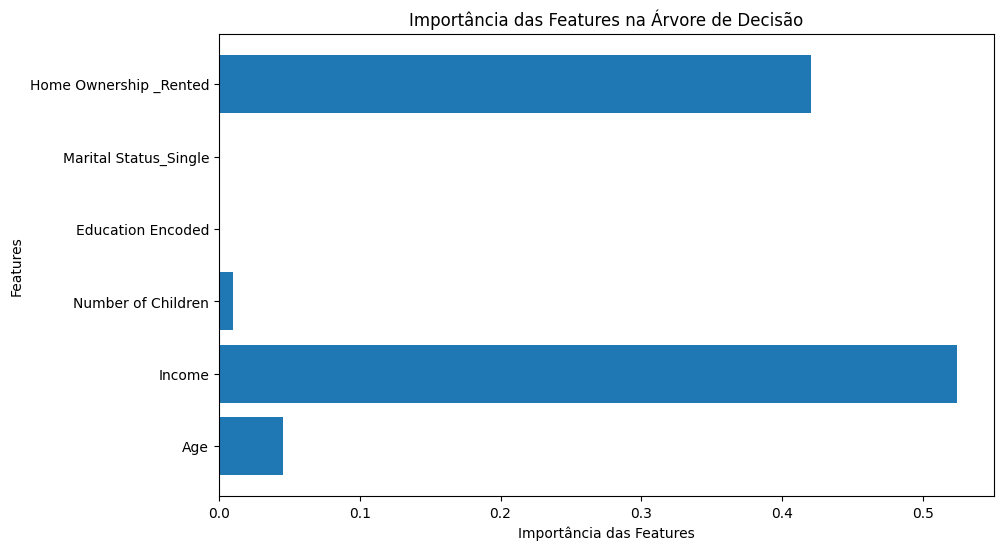

In [33]:
# Obtendo a importância das características do modelo de árvore de decisão
importancias_features = arvore_01.feature_importances_
print("Importância das Features:")
for nome, importancia in zip(X_train.columns, importancias_features):
    print(f"{nome}: {importancia:.4f}")
# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

# 7) Modelo de árvore de decisão reduzido

Apenas as 2 principais features encontradas (home ownership rented e income) serão mantidas nas bases de treino e teste.

In [41]:
X_train_reduzido = X_train[['Home Ownership _Rented', 'Income']]
X_test_reduzido = X_test[['Home Ownership _Rented', 'Income']]
arvore_02 = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_02.fit(X_train_reduzido, y_train)
previsoes_reduzido = arvore_02.predict(X_test_reduzido)
relatorio_02 = classification_report(y_test, previsoes_reduzido)



print("Relatório de Classificação Teste:")
print(relatorio_teste)
print("Relatório de Classificação Modelo reduzido:")
print(relatorio_02)


Relatório de Classificação Teste:
              precision    recall  f1-score   support

     Average       0.86      1.00      0.92         6
        High       1.00      0.97      0.98        29
         Low       1.00      1.00      1.00         6

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41

Relatório de Classificação Modelo reduzido:
              precision    recall  f1-score   support

     Average       0.83      0.83      0.83         6
        High       0.97      0.97      0.97        29
         Low       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



De maneira geral, os valores pioraram. Nosso variável alvo é a pontuação de crédito, mais especificamente aqueles clientes com um alto risco de inadinplência. A acurácia para esses clientes piorou, indicando que talvez seja encessário ioncluir mais algumas características para que o modelo fique bom.
# 8) Comparação entre os resultados da árvore de decisão com os resultados do Naive Bayes 

Os resultados com Naive Bayes foram Acurácia = 1.0 e Recall = 1.0. Já para a árvore de decisão foram Acurácia = 0.95 e Recall 0.83, 0.97, 1.0.
O modelo Naive Bayes teve um desempenho melhor, ou seja, classificou corretamente todos os casos e identificou todos os positivos sem erros. Já a árvore de decisão apresentou acurácia de 0.95 (ou seja, 95% das previsões corretas) e recall variando entre 0.83, 0.97 e 1.0 para diferentes classes, indicando que, para algumas classes, o modelo não identificou todos os casos corretamente. Isso sugere que o Naive Bayes está mais adequado para esse conjunto de dados, pois teve desempenho superior em todos os aspectos avaliados. Porém, é importante considerar se o resultado do Naive Bayes não está sofrendo de overfitting (acerto perfeito pode indicar isso, dependendo do tamanho e complexidade dos dados). 
É possível também que esteja ocorrendo um viés para a classe de alto risco, já que essa é a com maior quantidade de dados.